# SQL Trial Notebook
Rule: For every code cell I write or modify, I will append the exact code to Cell 2 (Code Log).

## Entry 13 - 2026-07-25
Purpose: White space targets available per solid tumor indication — the final whitespace cut. Cross-tabs the top 12 solid tumor indications (heme/liquid tumor types excluded via keyword filter) against the top 20 most-patented targets overall, flags zero-count cells as concrete whitespace (an established target with no patent yet for that specific solid tumor indication), and summarizes whitespace breadth and the most crowded target per indication. Chart pack: a red/green heatmap of the indication x target grid plus a ranked bar of whitespace breadth per indication.

```python
import pandas as pd

sql_solid_indication_target_grid = f'''
WITH expanded AS (
    SELECT COALESCE(target_corrected, target) AS t,
           TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS tumor
    FROM read_csv_auto('{csv_path.as_posix()}')
    WHERE indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
      AND COALESCE(target_corrected, target) IS NOT NULL
),
solid AS (
    SELECT t, tumor
    FROM expanded
    WHERE tumor NOT ILIKE '%leukemia%' AND tumor NOT ILIKE '%lymphoma%' AND tumor NOT ILIKE '%myeloma%'
      AND tumor NOT ILIKE '%CLL%' AND tumor NOT ILIKE '%AML%' AND tumor NOT ILIKE '%ALL%'
      AND tumor NOT ILIKE '%MDS%' AND tumor NOT ILIKE '%hodgkin%' AND tumor NOT ILIKE '%waldenstrom%'
      AND tumor NOT ILIKE '%blood%'
),
top_indications AS (
    SELECT tumor, COUNT(*) AS n FROM solid GROUP BY 1 ORDER BY n DESC LIMIT 12
),
top_targets AS (
    SELECT COALESCE(target_corrected, target) AS t, COUNT(*) AS n
    FROM read_csv_auto('{csv_path.as_posix()}')
    WHERE COALESCE(target_corrected, target) IS NOT NULL
    GROUP BY 1 ORDER BY n DESC LIMIT 20
),
combos AS (
    SELECT ti.tumor, tt.t
    FROM top_indications ti CROSS JOIN top_targets tt
),
actual AS (
    SELECT tumor, t, COUNT(*) AS n
    FROM solid
    WHERE tumor IN (SELECT tumor FROM top_indications) AND t IN (SELECT t FROM top_targets)
    GROUP BY 1, 2
)
SELECT combos.tumor AS indication, combos.t AS target_name, COALESCE(actual.n, 0) AS patent_count
FROM combos
LEFT JOIN actual ON actual.tumor = combos.tumor AND actual.t = combos.t
ORDER BY combos.tumor, patent_count DESC;
'''

solid_indication_target_grid_df = con.sql(sql_solid_indication_target_grid).df()

n_cells = len(solid_indication_target_grid_df)
n_zero = int((solid_indication_target_grid_df['patent_count'] == 0).sum())

display(Markdown('### H. Solid Tumor Indication x Target Whitespace Grid (top 12 solid tumor indications x top 20 targets)'))
display(solid_indication_target_grid_df)

display(Markdown(f'**{n_zero} of {n_cells} cells ({n_zero/n_cells:.0%})** have zero patents — i.e. that established target has no patent filed for that specific solid tumor indication in this dataset.'))

# Whitespace targets per indication: which of the 20 established targets are unclaimed for each indication
all_indications = solid_indication_target_grid_df['indication'].unique()
zero_df = solid_indication_target_grid_df[solid_indication_target_grid_df['patent_count'] == 0]
whitespace_targets_map = zero_df.groupby('indication')['target_name'].apply(lambda s: ', '.join(sorted(s)))
whitespace_count_map = zero_df.groupby('indication').size()

# Most crowded (highest patent count) target per indication, for context
top_crowded_df = (
    solid_indication_target_grid_df.sort_values('patent_count', ascending=False)
    .groupby('indication')
    .first()[['target_name', 'patent_count']]
    .rename(columns={'target_name': 'most_crowded_target', 'patent_count': 'most_crowded_target_patents'})
)

whitespace_per_indication_df = pd.DataFrame({'indication': all_indications})
whitespace_per_indication_df['whitespace_target_count'] = whitespace_per_indication_df['indication'].map(whitespace_count_map).fillna(0).astype(int)
whitespace_per_indication_df['whitespace_targets'] = whitespace_per_indication_df['indication'].map(whitespace_targets_map).fillna('(none — all 20 targets already claimed)')
whitespace_per_indication_df = whitespace_per_indication_df.merge(top_crowded_df, on='indication', how='left')
whitespace_per_indication_df = whitespace_per_indication_df.sort_values('whitespace_target_count', ascending=False).reset_index(drop=True)

display(Markdown('### Whitespace Targets Available per Solid Tumor Indication (out of 20 established targets considered)'))
display(whitespace_per_indication_df)
```

```python
import matplotlib.pyplot as plt

indication_order = whitespace_per_indication_df.sort_values('whitespace_target_count', ascending=False)['indication'].tolist()
target_order = solid_indication_target_grid_df.groupby('target_name')['patent_count'].sum().sort_values(ascending=False).index.tolist()
pivot_it = solid_indication_target_grid_df.pivot(index='indication', columns='target_name', values='patent_count').reindex(index=indication_order, columns=target_order)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [3, 1]})

# 1. Heatmap: solid tumor indication x target, patent counts (red = crowded, green/0 = whitespace)
ax = axes[0]
vmax = pivot_it.values.max()
im = ax.imshow(pivot_it.values, cmap='RdYlGn_r', vmin=0, vmax=vmax, aspect='auto')
for i in range(pivot_it.shape[0]):
    for j in range(pivot_it.shape[1]):
        val = int(pivot_it.values[i, j])
        ax.text(j, i, str(val), ha='center', va='center', fontsize=7,
                color='white' if val > vmax * 0.5 else 'black')
ax.set_xticks(range(len(pivot_it.columns)))
ax.set_xticklabels(pivot_it.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(pivot_it.index)))
ax.set_yticklabels(pivot_it.index, fontsize=9)
ax.set_title('Solid Tumor Indication x Target Whitespace (red = crowded, green/0 = unclaimed)')
fig.colorbar(im, ax=ax, label='Patent Count')

# 2. Whitespace breadth per indication (count of unclaimed established targets, out of 20)
ax2 = axes[1]
wb = whitespace_per_indication_df.sort_values('whitespace_target_count')
ax2.barh(wb['indication'], wb['whitespace_target_count'], color='#059669')
ax2.set_title('Whitespace Breadth per Indication\n(of 20 established targets)')
ax2.set_xlabel('Count of Unclaimed Targets')

plt.tight_layout()
plt.show()
```


In [1]:
import duckdb
from pathlib import Path
from IPython.display import display, Markdown

con = duckdb.connect()

csv_candidates = [
    Path('input/FINAL_master_plus_mab_addendum.csv'),
    Path('FINAL_master_plus_mab_addendum.csv'),
    Path('../FINAL_master_plus_mab_addendum.csv'),
]
csv_path = next((p for p in csv_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('Could not locate FINAL_master_plus_mab_addendum.csv')

sql_first_5 = f"""
SELECT *
FROM read_csv_auto('{csv_path.as_posix()}')
LIMIT 5;
"""

first_5_df = con.sql(sql_first_5).df()
display(Markdown('### First 5 Rows'))
display(first_5_df)

### First 5 Rows

,ip_master_id,publication_number,application_number,family_representative,authority,title,current_assignee,filing_year,application_date,publication_date,...,claims_excerpt,resolution_confidence,resolution_method,claims_fulltext,record_source,is_antibody,independent_claim_count,total_claim_count,epitope_competition_info,mentions_sequence_cdr
0,PUB:WO2010094720A3,WO2010094720A3,PCT/EP2010/052005,WO2010094720A3,WO,"Improved Anti-TNFR1 polypeptides, antibody var...","GLAXO GROUP LIMITED|DUFFIELD, STEPHEN|ENEVER, ...",2010,20100217,20100826,...,1. An anti-TNFα receptor type 1 (TNFRl ; p55) ...,high,local_full_claims,CLAIMS 1. An anti-TNFα receptor type 1 (TNFRl ...,master,None,<NA>,<NA>,None,<NA>
1,PUB:WO2010097394A1,WO2010097394A1,PCT/EP2010/052304,WO2010097394A1,WO,Multivalent and/or multispecific rankl-binding...,"GLAXO GROUP LIMITED|HAMBLIN, PAUL, ANDREW|PARM...",2010,20100223,20100902,...,An antigen-binding construct comprising a prot...,medium,google_patents_or_db_live,Claims 1. An antigen-binding construct compris...,master,None,<NA>,<NA>,None,<NA>
2,PUB:WO2010097825A1,WO2010097825A1,PCT/IT2010/000060,WO2010097825A1,WO,Use of Anti-90k monoclonal antibodies for the ...,IACOBELLI STEFANO,2010,20100218,20100902,...,NaN,NaN,NaN,CLAIMS 1). The use of an antibody able to bind...,master,None,<NA>,<NA>,None,<NA>
3,PUB:WO2010102167A1,WO2010102167A1,PCT/US2010/026300,WO2010102167A1,WO,Matrix metalloproteinase-7 (MMP-7) monoclonal ...,"TRIPATH IMAGING, INC.|BAKER, Jeffrey, P.|CHEEK...",2010,20100305,20100910,...,NaN,NaN,NaN,THAT WHICH IS CLAIMED: 1. A monoclonal antibod...,master,None,<NA>,<NA>,None,<NA>
4,PUB:WO2010102175A1,WO2010102175A1,PCT/US2010/026315,WO2010102175A1,WO,Fully human antibodies specific to CADM1,"MEDAREX, INC.|OXFORD BIOTHERAPEUTICS LTD|TERRE...",2010,20100305,20100910,...,"1. An isolated monoclonal antibody, or an anti...",low,local_full_claims,What is claimed: 1. An isolated monoclonal ant...,master,None,<NA>,<NA>,None,<NA>


In [2]:
sql_total_rows = f'''
SELECT COUNT(*) AS total_rows
FROM read_csv_auto('{csv_path.as_posix()}');
'''

sql_modality_counts = f'''
SELECT modality_only, COUNT(*) AS row_count
FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY modality_only
ORDER BY row_count DESC;
'''

sql_top_indications = f'''
SELECT TRIM(indications) AS indication, COUNT(*) AS row_count
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE indications IS NOT NULL AND TRIM(indications) <> ''
GROUP BY TRIM(indications)
ORDER BY row_count DESC
LIMIT 10;
'''

display(Markdown('### Analytics: Total Rows'))
display(con.sql(sql_total_rows).df())

display(Markdown('### Analytics: Rows by Modality'))
display(con.sql(sql_modality_counts).df())

display(Markdown('### Analytics: Top 10 Indication Strings'))
display(con.sql(sql_top_indications).df())

### Analytics: Total Rows

,total_rows
0,8901


### Analytics: Rows by Modality

,modality_only,row_count
0,MAB,6274
1,BISPECIFIC,1914
2,ADC,586
3,BISPECIFIC|ADC,91
4,PROTAC,25
5,BiTE,10
6,PROTAC|BISPECIFIC,1


### Analytics: Top 10 Indication Strings

,indication,row_count
0,oncology TA query hit,6107
1,Colorectal|Lung|Breast|Gastric / GEJ|Prostate|...,188
2,Lung,131
3,Breast,106
4,Colorectal|Lung|Breast|Gastric / GEJ|Prostate|...,87
5,Liver / HCC,83
6,Cervical,68
7,Sarcoma,58
8,Melanoma,56
9,Colorectal|Lung|Breast|Gastric / GEJ|Prostate|...,53


In [3]:
sql_overview = f'''
SELECT COUNT(*) AS total_rows, MIN(filing_year) AS min_year, MAX(filing_year) AS max_year
FROM read_csv_auto('{csv_path.as_posix()}');
'''

sql_is_antibody = f'''
SELECT is_antibody, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY is_antibody
ORDER BY n DESC;
'''

sql_authority = f'''
SELECT authority, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY authority
ORDER BY n DESC
LIMIT 15;
'''

sql_modality = f'''
SELECT modality_only, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY modality_only
ORDER BY n DESC
LIMIT 20;
'''

sql_top_targets = f'''
SELECT COALESCE(target_corrected, target) AS target_name, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY target_name
ORDER BY n DESC
LIMIT 25;
'''

sql_top_indications = f'''
SELECT TRIM(indications) AS indication, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE indications IS NOT NULL AND TRIM(indications) <> ''
GROUP BY indication
ORDER BY n DESC
LIMIT 25;
'''

sql_top_assignees = f'''
SELECT current_assignee, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE current_assignee IS NOT NULL
GROUP BY current_assignee
ORDER BY n DESC
LIMIT 25;
'''

sql_filing_trend = f'''
SELECT filing_year, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
WHERE filing_year IS NOT NULL
GROUP BY filing_year
ORDER BY filing_year;
'''

sql_category = f'''
SELECT category, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY category
ORDER BY n DESC
LIMIT 15;
'''

sql_claim_focus = f'''
SELECT claim_focus, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY claim_focus
ORDER BY n DESC
LIMIT 15;
'''

sql_crowding_relevance = f'''
SELECT crowding_relevance, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY crowding_relevance
ORDER BY n DESC
LIMIT 15;
'''

sql_resolution_confidence = f'''
SELECT resolution_confidence, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY resolution_confidence
ORDER BY n DESC;
'''

sql_record_source = f'''
SELECT record_source, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}')
GROUP BY record_source
ORDER BY n DESC;
'''

sql_avg_claims = f'''
SELECT AVG(independent_claim_count) AS avg_independent_claims,
       AVG(total_claim_count) AS avg_total_claims
FROM read_csv_auto('{csv_path.as_posix()}');
'''

sql_claim_disclosure = f'''
SELECT
  SUM(CASE WHEN claim_mentions_target THEN 1 ELSE 0 END) AS claim_mentions_target_n,
  SUM(CASE WHEN claim_mentions_sequence_or_cdr THEN 1 ELSE 0 END) AS claim_mentions_seq_cdr_n,
  SUM(CASE WHEN claim_mentions_epitope_domain_or_competition THEN 1 ELSE 0 END) AS claim_mentions_epitope_n,
  COUNT(*) AS total_rows
FROM read_csv_auto('{csv_path.as_posix()}');
'''

queries = [
    ("Overview (row count & filing year range)", sql_overview),
    ("is_antibody flag distribution", sql_is_antibody),
    ("Top authorities / jurisdictions", sql_authority),
    ("Modality distribution", sql_modality),
    ("Top 25 targets", sql_top_targets),
    ("Top 25 indications", sql_top_indications),
    ("Top 25 assignees / companies", sql_top_assignees),
    ("Filing trend by year", sql_filing_trend),
    ("Category distribution", sql_category),
    ("Claim focus distribution (top 15)", sql_claim_focus),
    ("Crowding relevance distribution (top 15)", sql_crowding_relevance),
    ("Resolution confidence distribution", sql_resolution_confidence),
    ("Record source distribution", sql_record_source),
    ("Average claim counts", sql_avg_claims),
    ("Claim disclosure depth flags", sql_claim_disclosure),
]

for title, sql in queries:
    display(Markdown(f'### {title}'))
    display(con.sql(sql).df())

### Overview (row count & filing year range)

,total_rows,min_year,max_year
0,8901,2010,2025


### is_antibody flag distribution

,is_antibody,n
0,NaN,8801
1,yes,53
2,no,27
3,?,20


### Top authorities / jurisdictions

...

,record_source,n
0,addendum_mab,6107
1,master,2794


### Average claim counts

,avg_independent_claims,avg_total_claims
0,3.428571,13.285714


### Claim disclosure depth flags

,claim_mentions_target_n,claim_mentions_seq_cdr_n,claim_mentions_epitope_n,total_rows
0,959.0,2451.0,1719.0,8901


# Insights (2026-07-23)

Based on the analytics above (8,901 records, filings 2010-2025).

## 1. Fast-growing, still-crowded space
Filings roughly tripled from 275/year (2010) to a peak of 874 (2023); 2024-2025 still running ~730-860/year. The space is still expanding, not consolidating.

## 2. Monoclonal antibodies dominate, but multispecifics are the growth engine
- MAB: 6,274 (70%)
- Bispecific: 1,914 (21%)
- ADC: 586 (7%), plus 91 hybrid Bispecific|ADC
- PROTAC/BiTE: 36 combined (emerging, low volume)

A pure mAb strategy competes in the most saturated segment. Bispecifics and ADCs are the more differentiated, less-crowded formats.

## 3. Target crowding is concentrated in a handful of "hot" antigens
PD-1 (282), HER2 (197), PD-L1 (178), EGFR (132), CD3 (116), CTLA-4 (72), B7-H3 (69), TROP-2 (65), CD47 (61) account for a large share of target-tagged patents. Checkpoint (PD-1/PD-L1/CTLA-4) and classic solid-tumor antigens (HER2/EGFR) are heavily fortified. Note: 3,086 of 8,901 rows have no resolved target - meaningful ambiguity that should be cleaned before treating target counts as a definitive crowding score.

## 4. Competitive landscape is led by large pharma, not startups
Roche/Genentech (~226 combined across related entity names), Regeneron (105), BMS (104), Janssen (78), Amgen (51), Novartis (42), Genmab (38), Seagen (36). Academic/government assignees (UC Regents 64, UT System 55, US Government 27, Johns Hopkins 26, MSKCC 25) are also heavily represented - in-licensing from academic institutions is a viable entry path, not just head-on competition with pharma.

## 5. Indications are overwhelmingly pan-oncology, not tumor-specific
6,107 of 8,901 rows (69%) are tagged only as "oncology TA query hit" - a generic catch-all with no specific tumor type resolved. Among rows with specific indications: Lung (131), Breast (106), Liver/HCC (83), Cervical (68), Sarcoma (58), Melanoma (56). Several large blocks list 14-17 indications simultaneously (broad platform claims), signaling combination/multi-indication filing strategies rather than indication-specific programs.

## 6. Data quality / annotation is uneven - a key caveat
- `is_antibody`: 8,801 of 8,901 (99%) are null/unflagged - essentially unpopulated and unreliable.
- `resolution_confidence`: only 4,832 of 8,901 rows have any confidence rating; of those, 682 are low/low-REVIEW (~15% flagged for manual review).
- `category`, `claim_focus`, and `crowding_relevance` are populated on only a small curated subset (rich narrative fields exist for a tiny slice, not the whole dataset).
- 6,107 rows (69%) come from `record_source = addendum_mab` (a bulk/broad pull) vs. 2,794 from the curated `master` table - the addendum rows are likely the source of most unresolved nulls above.

## 7. Claim strength / disclosure depth is thin on average
Average 3.4 independent claims / 13.3 total claims (computed only on the ~2,794 master rows with populated claim counts). Only 959 rows explicitly flag claim-level target mentions, 2,451 flag sequence/CDR claims, and 1,719 flag epitope/domain/competition claims - most patents in this set lack deep sequence-level (CDR) claim disclosure, which is favorable for designing around competitor epitopes since exact binding-site claims (the hardest to design around) are relatively rare here.

## 8. Jurisdiction coverage is a blind spot
8,885 of 8,901 rows (99.8%) are WO (PCT) filings - this table only captures international applications, not national-phase entries (US, EP, CN, JP) that determine enforceable rights per market. Any FTO or filing-strategy decision needs this dataset supplemented with national-phase family data.

## Bottom line for a new antibody program
- **Whitespace signal:** mid-tier targets (CLDN18.2, TIGIT, CD73, CD137, MET, OX40, Mesothelin, CCR8 - all 36-51 patents) are far less fortified than PD-1/HER2/EGFR, and could be lower-risk entry points.
- **Format signal:** bispecifics/ADCs are growing faster than plain mAbs and are less saturated in absolute count, but require harder CMC/manufacturing capability.
- **Indication signal:** the "oncology TA query hit" catch-all means indication-specific whitespace can't be reliably assessed yet - needs a follow-up cleaning pass (parsing pipe-delimited indication lists into a proper many-to-many table).
- **Data caveat:** roughly a third of the dataset (target, category, claim_focus, crowding_relevance) is sparsely populated - a data-cleaning pass to backfill target/indication resolution on the addendum rows is recommended before treating these as board-level numbers.


## Deep-dive: Indication whitespace, target x modality crowding, target scoring

Follow-up analytics requested during the strategy interview: parsing the pipe-delimited indication lists into individual tumor types, cross-tabbing the top 15 targets against modality, and scoring targets by patent count, assignee diversity, and recent filing momentum.

In [4]:
sql_indication_whitespace = f'''
WITH split AS (
  SELECT UNNEST(STR_SPLIT(TRIM(indications), '|')) AS tumor_type
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE indications IS NOT NULL AND TRIM(indications) <> ''
    AND TRIM(indications) <> 'oncology TA query hit'
)
SELECT TRIM(tumor_type) AS tumor_type, COUNT(*) AS n
FROM split
GROUP BY 1
ORDER BY n DESC;
'''

sql_target_modality_matrix = f'''
WITH top_targets AS (
  SELECT COALESCE(target_corrected, target) AS t, COUNT(*) AS n
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE COALESCE(target_corrected, target) IS NOT NULL
  GROUP BY 1 ORDER BY n DESC LIMIT 15
)
SELECT COALESCE(d.target_corrected, d.target) AS target_name, d.modality_only, COUNT(*) AS n
FROM read_csv_auto('{csv_path.as_posix()}') d
JOIN top_targets tt ON COALESCE(d.target_corrected, d.target) = tt.t
GROUP BY 1,2
ORDER BY target_name, n DESC;
'''

sql_target_whitespace_score = f'''
WITH base AS (
  SELECT COALESCE(target_corrected, target) AS t, current_assignee, filing_year
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE COALESCE(target_corrected, target) IS NOT NULL
)
SELECT t AS target_name,
       COUNT(*) AS total_patents,
       COUNT(DISTINCT current_assignee) AS unique_assignees,
       SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) AS filed_last_3y
FROM base
GROUP BY 1
HAVING COUNT(*) >= 10
ORDER BY total_patents DESC
LIMIT 30;
'''

indication_whitespace_df = con.sql(sql_indication_whitespace).df()
target_modality_matrix_df = con.sql(sql_target_modality_matrix).df()
target_whitespace_score_df = con.sql(sql_target_whitespace_score).df()

display(Markdown('### Parsed Indication Whitespace (individual tumor types, excluding generic catch-all)'))
display(indication_whitespace_df)

display(Markdown('### Target x Modality Crowding Matrix (top 15 targets)'))
display(target_modality_matrix_df)

display(Markdown('### Target Whitespace Scoring (count, assignee diversity, recent momentum)'))
display(target_whitespace_score_df)

### Parsed Indication Whitespace (individual tumor types, excluding generic catch-all)

,tumor_type,n
0,Lung,1855
1,Breast,1806
2,Colorectal,1575
3,Ovarian,1487
4,Melanoma,1482
5,Pancreatic,1477
6,Prostate,1425
7,Kidney / RCC,1341
8,Gastric / GEJ,1340
9,Glioblastoma / brain,1338


### Target x Modality Crowding Matrix (top 15 targets)

,target_name,modality_only,n
0,B7-H3,MAB,34
1,B7-H3,ADC,30
2,B7-H3,BISPECIFIC,4
3,B7-H3,BISPECIFIC|ADC,1
4,CD137,MAB,40
5,CD137,BISPECIFIC,3
6,CD137,ADC,2
7,CD20 x CD3,BISPECIFIC,43
8,CD20 x CD3,BISPECIFIC|ADC,3
9,CD20 x CD3,BiTE,1


### Target Whitespace Scoring (count, assignee diversity, recent momentum)

,target_name,total_patents,unique_assignees,filed_last_3y
0,PD-1,282,210,72.0
1,HER2,197,133,84.0
2,PD-L1,178,131,43.0
3,EGFR,132,104,30.0
4,CD3,116,87,39.0
5,CTLA-4,72,57,31.0
6,B7-H3,69,51,38.0
7,TROP-2,65,48,38.0
8,CD47,61,51,7.0
9,TCR,53,41,16.0


# Charts

Visualizations of the analytics above, plus two deeper cuts requested during the strategy interview: parsed indication whitespace (splitting the pipe-delimited tumor-type lists) and a target x modality crowding matrix for the top 15 targets.

/var/folders/k_/q9w49kk53zg7v019tx90gbjh0000gn/T/ipykernel_2995/3562718151.py:48: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/q9w49kk53zg7v019tx90gbjh0000gn/T/ipykernel_2995/3562718151.py:48: UserWarning: Glyph 24029 (\N{CJK UNIFIED IDEOGRAPH-5DDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/q9w49kk53zg7v019tx90gbjh0000gn/T/ipykernel_2995/3562718151.py:48: UserWarning: Glyph 31185 (\N{CJK UNIFIED IDEOGRAPH-79D1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/q9w49kk53zg7v019tx90gbjh0000gn/T/ipykernel_2995/3562718151.py:48: UserWarning: Glyph 20262 (\N{CJK UNIFIED IDEOGRAPH-4F26}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/q9w49kk53zg7v019tx90gbjh0000gn/T/ipykernel_2995/3562718151.py:48: UserWarning: Glyph 21338 (\N{CJK UNIFIED IDEOGRAPH-535A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/q9w49kk53

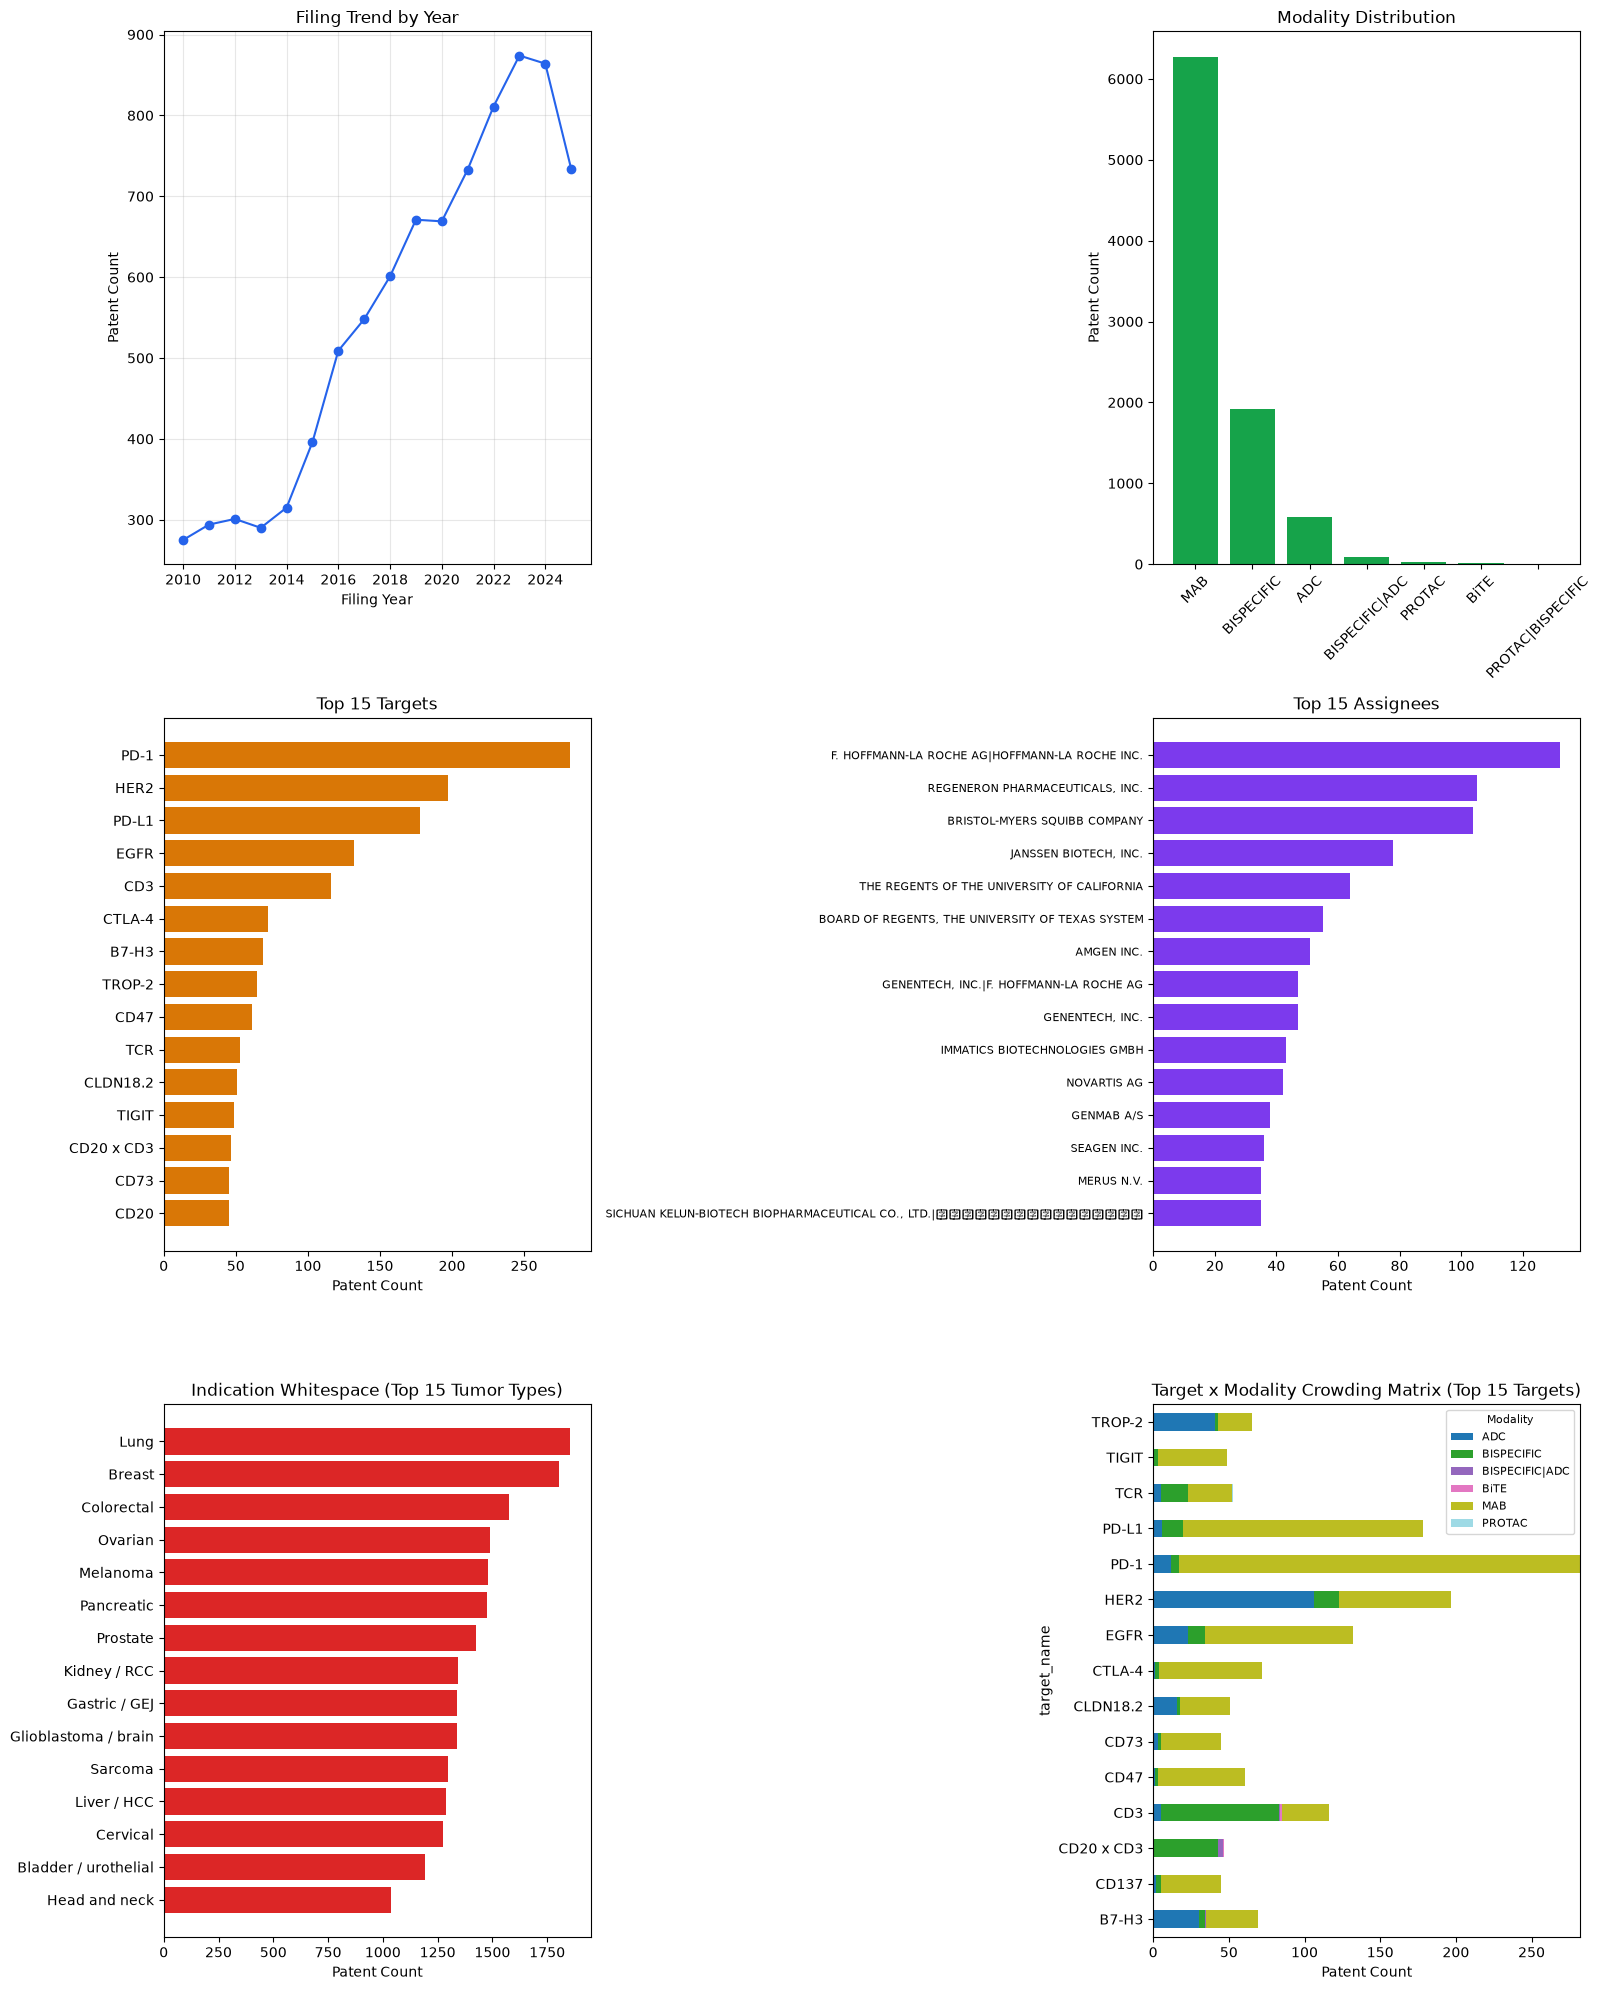

In [5]:
import matplotlib.pyplot as plt

# Re-run underlying SQL (data already fetched above; re-querying keeps this cell independent)
filing_trend_df = con.sql(sql_filing_trend).df()
modality_df = con.sql(sql_modality).df()
top_targets_df = con.sql(sql_top_targets).df().dropna(subset=['target_name']).head(15)
top_assignees_df = con.sql(sql_top_assignees).df().head(15)
indication_df = indication_whitespace_df.head(15)
matrix_df = target_modality_matrix_df.pivot(index='target_name', columns='modality_only', values='n').fillna(0)

fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# 1. Filing trend by year
axes[0, 0].plot(filing_trend_df['filing_year'], filing_trend_df['n'], marker='o', color='#2563eb')
axes[0, 0].set_title('Filing Trend by Year')
axes[0, 0].set_xlabel('Filing Year')
axes[0, 0].set_ylabel('Patent Count')
axes[0, 0].grid(alpha=0.3)

# 2. Modality distribution
axes[0, 1].bar(modality_df['modality_only'], modality_df['n'], color='#16a34a')
axes[0, 1].set_title('Modality Distribution')
axes[0, 1].set_ylabel('Patent Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Top 15 targets
axes[1, 0].barh(top_targets_df['target_name'][::-1], top_targets_df['n'][::-1], color='#d97706')
axes[1, 0].set_title('Top 15 Targets')
axes[1, 0].set_xlabel('Patent Count')

# 4. Top 15 assignees
axes[1, 1].barh(top_assignees_df['current_assignee'][::-1], top_assignees_df['n'][::-1], color='#7c3aed')
axes[1, 1].set_title('Top 15 Assignees')
axes[1, 1].set_xlabel('Patent Count')
axes[1, 1].tick_params(axis='y', labelsize=8)

# 5. Indication whitespace (parsed, top 15 tumor types)
axes[2, 0].barh(indication_df['tumor_type'][::-1], indication_df['n'][::-1], color='#dc2626')
axes[2, 0].set_title('Indication Whitespace (Top 15 Tumor Types)')
axes[2, 0].set_xlabel('Patent Count')

# 6. Target x Modality crowding matrix (stacked bar)
matrix_df.plot(kind='barh', stacked=True, ax=axes[2, 1], colormap='tab20')
axes[2, 1].set_title('Target x Modality Crowding Matrix (Top 15 Targets)')
axes[2, 1].set_xlabel('Patent Count')
axes[2, 1].legend(title='Modality', fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()

## Target Whitespace — Multi-Angle Analysis

Four complementary views of target whitespace, as requested during the strategy interview:
- **(A)** Target-level summary: patent count, assignee diversity, modality diversity, indication-resolution rate, and recent (2023+) filing momentum — the "with indication vs. without indication" split.
- **(B)** Target x Modality share — which formats (MAB/ADC/BISPECIFIC/etc.) already dominate each target's IP, revealing modality-specific whitespace.
- **(C)** Target x Indication crowding matrix — top 12 targets x top 12 tumor types, showing indication-specific crowding within each target.
- **(D)** Whitespace quadrant classification — targets bucketed into Hot/Crowded, Mature/Legacy, Emerging Whitespace, and Quiet/Underexplored based on total volume and recent filing momentum.

In [6]:
sql_target_whitespace_summary = f'''
WITH base AS (
  SELECT COALESCE(target_corrected, target) AS t, current_assignee, filing_year, modality_only,
         CASE WHEN indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit') THEN 1 ELSE 0 END AS has_specific_indication
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE COALESCE(target_corrected, target) IS NOT NULL
)
SELECT t AS target_name,
       COUNT(*) AS total_patents,
       COUNT(DISTINCT current_assignee) AS unique_assignees,
       COUNT(DISTINCT modality_only) AS distinct_modalities,
       SUM(has_specific_indication) AS patents_with_specific_indication,
       COUNT(*) - SUM(has_specific_indication) AS patents_generic_oncology_only,
       ROUND(100.0 * SUM(has_specific_indication) / COUNT(*), 1) AS pct_indication_resolved,
       SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) AS filed_last_3y,
       ROUND(100.0 * SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_recent
FROM base
GROUP BY 1
HAVING COUNT(*) >= 8
ORDER BY total_patents DESC;
'''

sql_target_modality_share = f'''
WITH base AS (
  SELECT COALESCE(target_corrected, target) AS t, modality_only
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE COALESCE(target_corrected, target) IS NOT NULL
),
tot AS (SELECT t, COUNT(*) AS total FROM base GROUP BY 1)
SELECT b.t AS target_name, b.modality_only, COUNT(*) AS n,
       ROUND(100.0*COUNT(*)/tot.total,1) AS pct_of_target
FROM base b JOIN tot ON b.t = tot.t
WHERE tot.total >= 15
GROUP BY 1,2,tot.total
ORDER BY target_name, n DESC;
'''

sql_target_indication_matrix = f'''
WITH expanded AS (
  SELECT COALESCE(target_corrected, target) AS t,
         TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS tumor
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
    AND COALESCE(target_corrected, target) IS NOT NULL
),
top_t AS (
  SELECT COALESCE(target_corrected, target) AS t, COUNT(*) n
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE COALESCE(target_corrected, target) IS NOT NULL
  GROUP BY 1 ORDER BY n DESC LIMIT 12
),
top_i AS (
  SELECT tumor, COUNT(*) n FROM expanded GROUP BY 1 ORDER BY n DESC LIMIT 12
)
SELECT e.t AS target_name, e.tumor AS indication, COUNT(*) AS n
FROM expanded e
JOIN top_t ON e.t = top_t.t
JOIN top_i ON e.tumor = top_i.tumor
GROUP BY 1,2
ORDER BY target_name, n DESC;
'''

sql_target_quadrant = f'''
WITH base AS (
  SELECT COALESCE(target_corrected, target) AS t, filing_year
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE COALESCE(target_corrected, target) IS NOT NULL
),
agg AS (
  SELECT t AS target_name, COUNT(*) AS total_patents,
         SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) AS recent_3y,
         ROUND(100.0*SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_recent
  FROM base GROUP BY 1 HAVING COUNT(*) >= 8
)
SELECT target_name, total_patents, recent_3y, pct_recent,
  CASE
    WHEN total_patents >= 40 AND pct_recent >= 30 THEN 'Hot/Crowded (high volume, high momentum)'
    WHEN total_patents >= 40 AND pct_recent < 30 THEN 'Mature/Legacy (high volume, cooling)'
    WHEN total_patents < 40 AND pct_recent >= 30 THEN 'Emerging Whitespace (low volume, accelerating)'
    ELSE 'Quiet/Underexplored (low volume, low momentum)'
  END AS whitespace_quadrant
FROM agg
ORDER BY pct_recent DESC, total_patents ASC;
'''

target_whitespace_summary_df = con.sql(sql_target_whitespace_summary).df()
target_modality_share_df = con.sql(sql_target_modality_share).df()
target_indication_matrix_df = con.sql(sql_target_indication_matrix).df()
target_quadrant_df = con.sql(sql_target_quadrant).df()

display(Markdown('### A. Target-level Whitespace Summary (indication resolution + recency)'))
display(target_whitespace_summary_df)

display(Markdown('### B. Target x Modality Share (whitespace by format)'))
display(target_modality_share_df)

display(Markdown('### C. Target x Indication Crowding Matrix (top 12 targets x top 12 indications)'))
display(target_indication_matrix_df)

display(Markdown('### D. Whitespace Quadrant Classification (volume x recent momentum)'))
display(target_quadrant_df)

### A. Target-level Whitespace Summary (indication resolution + recency)

,target_name,total_patents,unique_assignees,distinct_modalities,patents_with_specific_indication,patents_generic_oncology_only,pct_indication_resolved,filed_last_3y,pct_recent
0,PD-1,282,210,3,27.0,255.0,9.6,72.0,25.5
1,HER2,197,133,3,127.0,70.0,64.5,84.0,42.6
2,PD-L1,178,131,3,21.0,157.0,11.8,43.0,24.2
3,EGFR,132,104,3,42.0,90.0,31.8,30.0,22.7
4,CD3,116,87,5,86.0,30.0,74.1,39.0,33.6
...,...,...,...,...,...,...,...,...,...
129,PD-1 x CTLA-4,8,7,1,8.0,0.0,100.0,3.0,37.5
130,PD-L1 x VEGF,8,8,2,8.0,0.0,100.0,4.0,50.0
131,RON,8,8,2,3.0,5.0,37.5,2.0,25.0
132,GCC,8,6,3,3.0,5.0,37.5,4.0,50.0


### B. Target x Modality Share (whitespace by format)

,target_name,modality_only,n,pct_of_target
0,AXL,MAB,17,68.0
1,AXL,ADC,7,28.0
2,AXL,BISPECIFIC,1,4.0
3,B7-H3,MAB,34,49.3
4,B7-H3,ADC,30,43.5
...,...,...,...,...
150,VEGF,ADC,2,5.4
151,VEGFR2,MAB,19,95.0
152,VEGFR2,ADC,1,5.0
153,VISTA,MAB,21,100.0


### C. Target x Indication Crowding Matrix (top 12 targets x top 12 indications)

,target_name,indication,n
0,B7-H3,Lung,29
1,B7-H3,Prostate,14
2,B7-H3,Breast,14
3,B7-H3,Glioblastoma / brain,13
4,B7-H3,Colorectal,11
...,...,...,...
139,TROP-2,Liver / HCC,16
140,TROP-2,Glioblastoma / brain,15
141,TROP-2,Kidney / RCC,15
142,TROP-2,Melanoma,13


### D. Whitespace Quadrant Classification (volume x recent momentum)

,target_name,total_patents,recent_3y,pct_recent,whitespace_quadrant
0,MET x EGFR,11,10.0,90.9,"Emerging Whitespace (low volume, accelerating)"
1,PTK7,8,7.0,87.5,"Emerging Whitespace (low volume, accelerating)"
2,DLL3,31,24.0,77.4,"Emerging Whitespace (low volume, accelerating)"
3,GPRC5D x CD3,13,10.0,76.9,"Emerging Whitespace (low volume, accelerating)"
4,CRBN,8,6.0,75.0,"Emerging Whitespace (low volume, accelerating)"
...,...,...,...,...,...
129,galectin-9,12,1.0,8.3,"Quiet/Underexplored (low volume, low momentum)"
130,CEA x CD3,13,1.0,7.7,"Quiet/Underexplored (low volume, low momentum)"
131,using,15,1.0,6.7,"Quiet/Underexplored (low volume, low momentum)"
132,DR5,16,1.0,6.3,"Quiet/Underexplored (low volume, low momentum)"


### Target Whitespace Charts

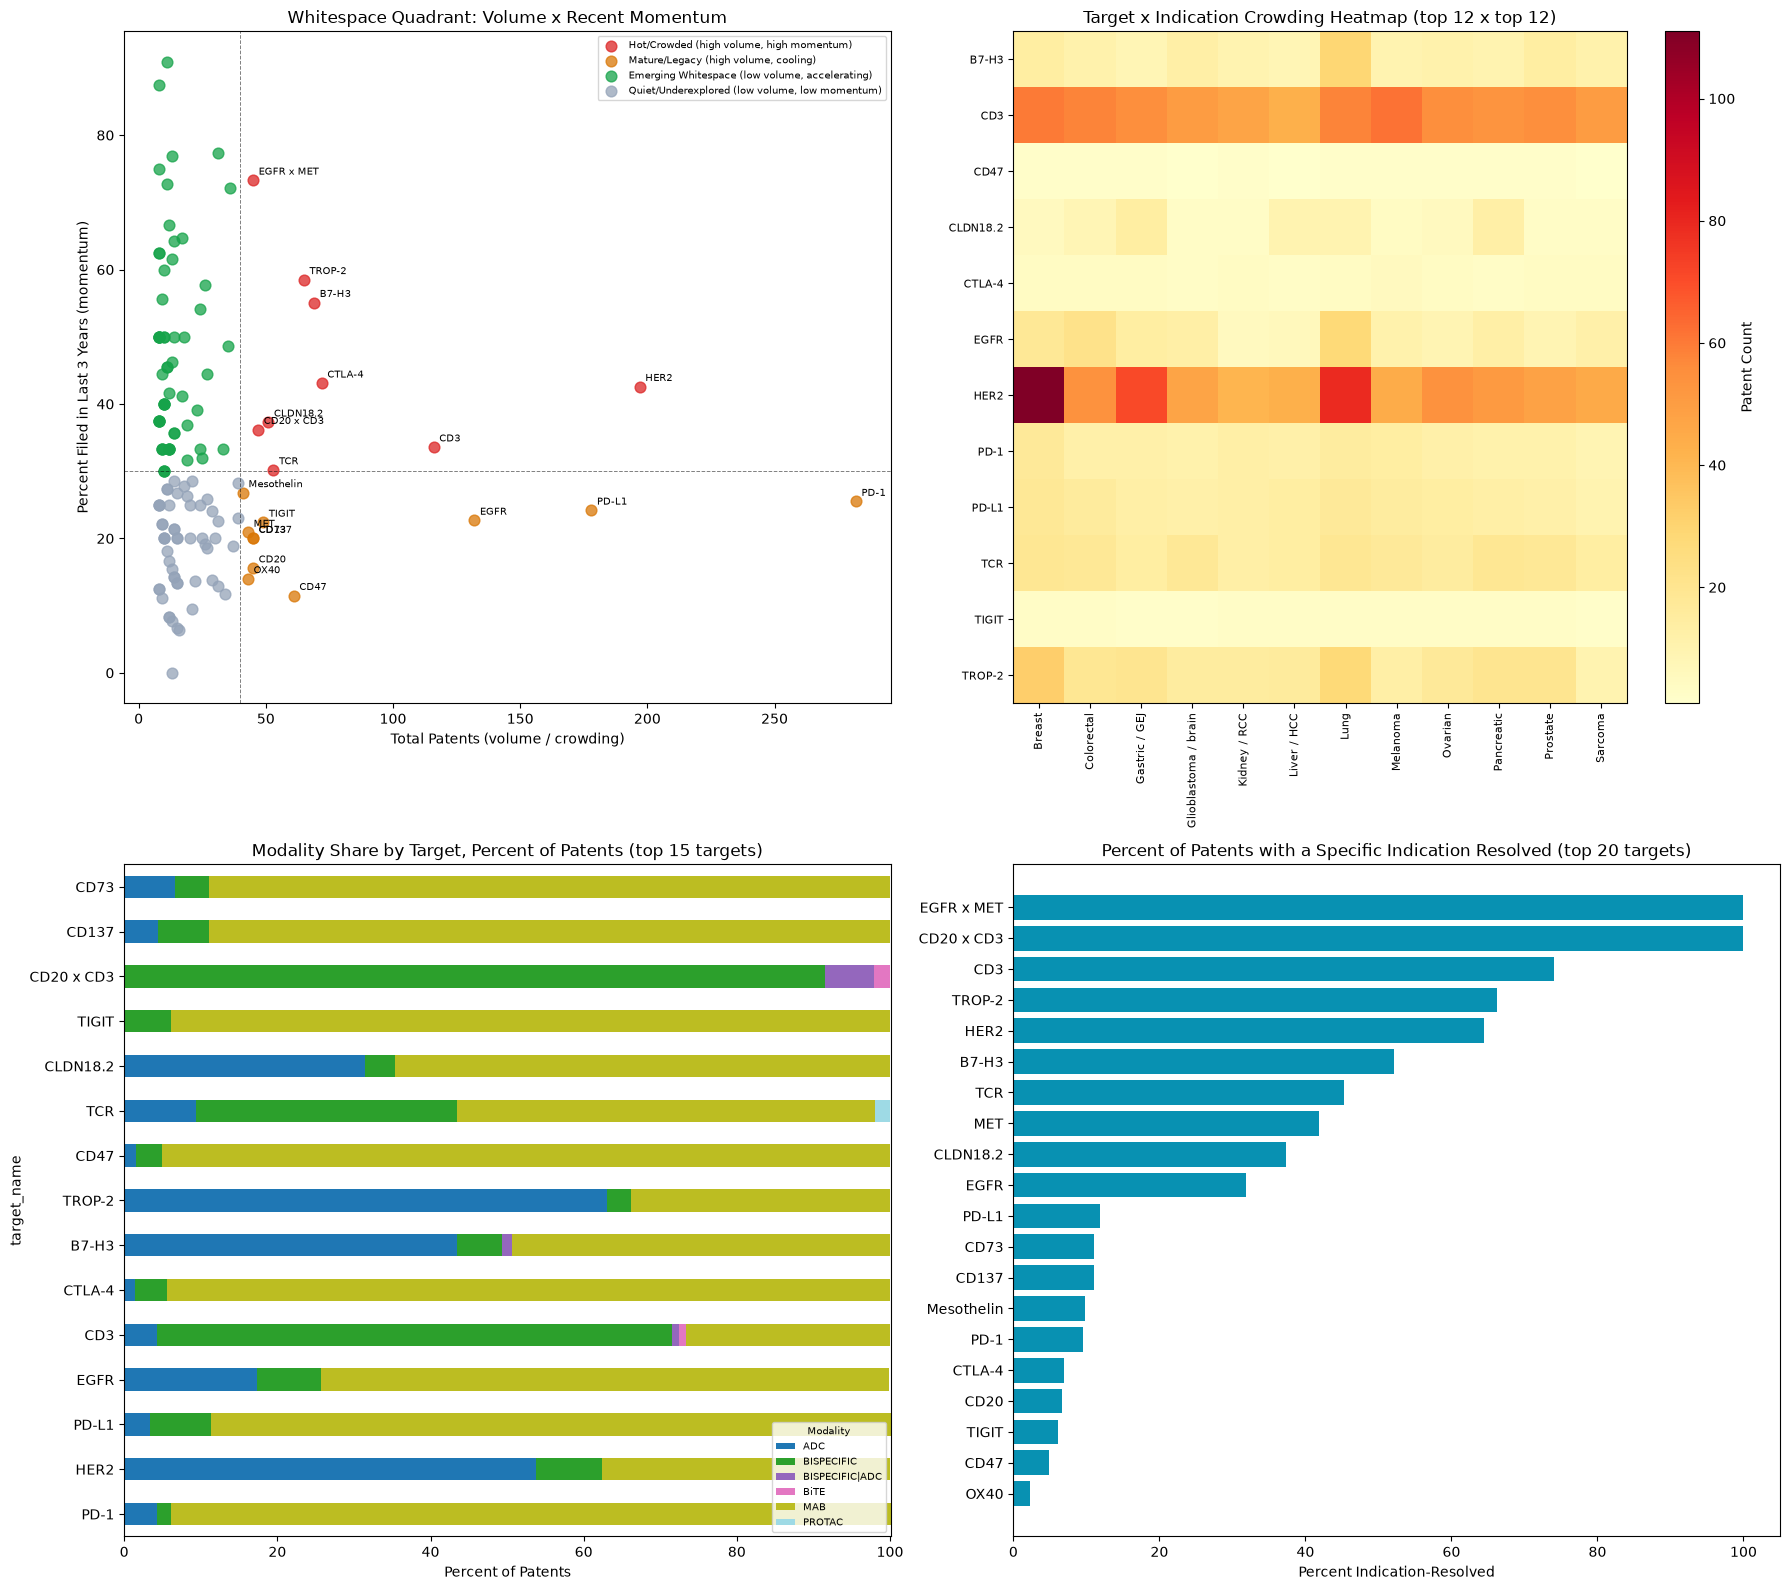

In [7]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# 1. Whitespace quadrant scatter: total volume vs recent momentum
quadrant_colors = {
    'Hot/Crowded (high volume, high momentum)': '#dc2626',
    'Mature/Legacy (high volume, cooling)': '#d97706',
    'Emerging Whitespace (low volume, accelerating)': '#16a34a',
    'Quiet/Underexplored (low volume, low momentum)': '#94a3b8',
}
ax = axes[0, 0]
for label, color in quadrant_colors.items():
    subset = target_quadrant_df[target_quadrant_df['whitespace_quadrant'] == label]
    ax.scatter(subset['total_patents'], subset['pct_recent'], label=label, color=color, alpha=0.75, s=60)
# Label the top 20 targets by patent volume to keep the chart readable
top20 = target_quadrant_df.nlargest(20, 'total_patents')
for _, row in top20.iterrows():
    ax.annotate(row['target_name'], (row['total_patents'], row['pct_recent']), fontsize=7, xytext=(4, 4), textcoords='offset points')
ax.axvline(40, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
ax.axhline(30, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlabel('Total Patents (volume / crowding)')
ax.set_ylabel('Percent Filed in Last 3 Years (momentum)')
ax.set_title('Whitespace Quadrant: Volume x Recent Momentum')
ax.legend(fontsize=7, loc='upper right')

# 2. Target x Indication crowding heatmap (top 12 x top 12)
ax = axes[0, 1]
pivot_ti = target_indication_matrix_df.pivot(index='target_name', columns='indication', values='n').fillna(0)
im = ax.imshow(pivot_ti.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(pivot_ti.columns)))
ax.set_xticklabels(pivot_ti.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(pivot_ti.index)))
ax.set_yticklabels(pivot_ti.index, fontsize=8)
ax.set_title('Target x Indication Crowding Heatmap (top 12 x top 12)')
fig.colorbar(im, ax=ax, label='Patent Count')

# 3. Target x Modality share (top 15 targets by total patents)
ax = axes[1, 0]
top15_targets = target_whitespace_summary_df.nlargest(15, 'total_patents')['target_name'].tolist()
share_pivot = target_modality_share_df[target_modality_share_df['target_name'].isin(top15_targets)].pivot(
    index='target_name', columns='modality_only', values='pct_of_target').reindex(top15_targets).fillna(0)
share_pivot.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Modality Share by Target, Percent of Patents (top 15 targets)')
ax.set_xlabel('Percent of Patents')
ax.legend(title='Modality', fontsize=7, title_fontsize=7)

# 4. Indication resolution rate (top 20 targets by volume)
ax = axes[1, 1]
top20_res = target_whitespace_summary_df.nlargest(20, 'total_patents').sort_values('pct_indication_resolved')
ax.barh(top20_res['target_name'], top20_res['pct_indication_resolved'], color='#0891b2')
ax.set_title('Percent of Patents with a Specific Indication Resolved (top 20 targets)')
ax.set_xlabel('Percent Indication-Resolved')

plt.tight_layout()
plt.show()

## Deep-Dive: Emerging Whitespace Targets (Low Volume, Accelerating)

The "Emerging Whitespace" quadrant (fewer than 40 total patents, but 30%+ filed in 2023+) is the most strategically interesting space for a new entrant: real, accelerating IP activity, but not yet crowded. This section expands that quadrant with:
- **(E)** A full deep-dive table per emerging-whitespace target: total patents, first/latest filing year, unique assignee count, the single top (leading) assignee and its share of that target's IP (competitive concentration), the dominant modality and its share, and the % of patents with a specific (non-generic) indication resolved.
- **(F)** Year-by-year filing counts (2015-2025) for these same targets, to visualize the acceleration curve.

In [8]:
sql_emerging_deepdive = f'''
WITH base AS (
  SELECT COALESCE(target_corrected, target) AS t, current_assignee, filing_year, modality_only,
         CASE WHEN indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit') THEN TRIM(indications) ELSE NULL END AS ind
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE COALESCE(target_corrected, target) IS NOT NULL
),
class AS (
  SELECT t, COUNT(*) total_patents,
         SUM(CASE WHEN filing_year>=2023 THEN 1 ELSE 0 END) recent_3y,
         ROUND(100.0*SUM(CASE WHEN filing_year>=2023 THEN 1 ELSE 0 END)/COUNT(*),1) pct_recent
  FROM base GROUP BY 1 HAVING COUNT(*)>=8
),
emerging AS (
  SELECT t FROM class WHERE total_patents < 40 AND pct_recent >= 30
),
assignee_rank AS (
  SELECT t, current_assignee, COUNT(*) n,
         ROW_NUMBER() OVER (PARTITION BY t ORDER BY COUNT(*) DESC) rn
  FROM base WHERE t IN (SELECT t FROM emerging)
  GROUP BY 1,2
),
top_assignee AS (
  SELECT t, current_assignee AS top_assignee, n AS top_assignee_patents
  FROM assignee_rank WHERE rn = 1
),
modality_rank AS (
  SELECT t, modality_only, COUNT(*) n,
         ROW_NUMBER() OVER (PARTITION BY t ORDER BY COUNT(*) DESC) rn
  FROM base WHERE t IN (SELECT t FROM emerging)
  GROUP BY 1,2
),
top_modality AS (
  SELECT t, modality_only AS dominant_modality, n AS dominant_modality_patents
  FROM modality_rank WHERE rn = 1
),
extra AS (
  SELECT t, MIN(filing_year) min_year, MAX(filing_year) max_year,
         COUNT(DISTINCT current_assignee) unique_assignees,
         SUM(CASE WHEN ind IS NOT NULL THEN 1 ELSE 0 END) specific_indication_patents
  FROM base WHERE t IN (SELECT t FROM emerging)
  GROUP BY 1
)
SELECT c.t AS target_name, c.total_patents, c.recent_3y, c.pct_recent,
       e.min_year AS first_filing_year, e.max_year AS latest_filing_year,
       e.unique_assignees,
       ta.top_assignee, ta.top_assignee_patents,
       ROUND(100.0*ta.top_assignee_patents/c.total_patents,1) AS top_assignee_share_pct,
       tm.dominant_modality, ROUND(100.0*tm.dominant_modality_patents/c.total_patents,1) AS dominant_modality_pct,
       e.specific_indication_patents, ROUND(100.0*e.specific_indication_patents/c.total_patents,1) AS pct_indication_resolved
FROM class c
JOIN emerging em ON c.t = em.t
JOIN extra e ON e.t = c.t
JOIN top_assignee ta ON ta.t = c.t
JOIN top_modality tm ON tm.t = c.t
ORDER BY c.pct_recent DESC, c.total_patents DESC;
'''

sql_emerging_trend = f'''
WITH base AS (
  SELECT COALESCE(target_corrected, target) AS t, filing_year
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE COALESCE(target_corrected, target) IS NOT NULL
),
class AS (
  SELECT t, COUNT(*) total_patents,
         ROUND(100.0*SUM(CASE WHEN filing_year>=2023 THEN 1 ELSE 0 END)/COUNT(*),1) pct_recent
  FROM base GROUP BY 1 HAVING COUNT(*)>=8
),
emerging AS (
  SELECT t FROM class WHERE total_patents < 40 AND pct_recent >= 30
)
SELECT t AS target_name, filing_year, COUNT(*) AS n
FROM base
WHERE t IN (SELECT t FROM emerging) AND filing_year BETWEEN 2015 AND 2025
GROUP BY 1,2
ORDER BY target_name, filing_year;
'''

emerging_deepdive_df = con.sql(sql_emerging_deepdive).df()
emerging_trend_df = con.sql(sql_emerging_trend).df()

display(Markdown('### E. Emerging Whitespace Deep-Dive (all qualifying targets, ranked by momentum)'))
display(emerging_deepdive_df)

display(Markdown(f'**{len(emerging_deepdive_df)} targets** qualify as Emerging Whitespace (under 40 total patents, 30%+ filed since 2023).'))

display(Markdown('### F. Emerging Whitespace Filing Trend by Year (2015-2025)'))
display(emerging_trend_df)

### E. Emerging Whitespace Deep-Dive (all qualifying targets, ranked by momentum)

,target_name,total_patents,recent_3y,pct_recent,first_filing_year,latest_filing_year,unique_assignees,top_assignee,top_assignee_patents,top_assignee_share_pct,dominant_modality,dominant_modality_pct,specific_indication_patents,pct_indication_resolved
0,MET x EGFR,11,10.0,90.9,2022,2025,10,"SICHUAN KELUN-BIOTECH BIOPHARMACEUTICAL CO., LTD.",2,18.2,BISPECIFIC,63.6,11.0,100.0
1,PTK7,8,7.0,87.5,2021,2025,7,"UIF (UNIVERSITY INDUSTRY FOUNDATION), YONSEI U...",2,25.0,MAB,75.0,3.0,37.5
2,DLL3,31,24.0,77.4,2011,2025,25,MEMORIAL SLOAN KETTERING CANCER CENTER|TRI-INS...,2,6.5,MAB,48.4,16.0,51.6
3,GPRC5D x CD3,13,10.0,76.9,2017,2025,7,F. HOFFMANN-LA ROCHE AG|HOFFMANN-LA ROCHE INC.,4,30.8,BISPECIFIC,100.0,13.0,100.0
4,CRBN,8,6.0,75.0,2020,2025,8,UNIVERSITY OF ULSAN FOUNDATION FOR INDUSTRY CO...,1,12.5,PROTAC,87.5,8.0,100.0
5,FCRH5 x CD3,11,8.0,72.7,2021,2025,4,"GENENTECH, INC.",7,63.6,BISPECIFIC,100.0,11.0,100.0
6,CCR8,36,26.0,72.2,2017,2025,30,DOMAIN THERAPEUTICS,5,13.9,MAB,97.2,1.0,2.8
7,CD8,12,8.0,66.7,2013,2025,11,THE REGENTS OF THE UNIVERSITY OF CALIFORNIA,2,16.7,MAB,50.0,6.0,50.0
8,CD24,17,11.0,64.7,2019,2025,16,"PHEAST THERAPEUTICS, INC.",2,11.8,MAB,94.1,2.0,11.8
9,FOLR1,14,9.0,64.3,2012,2025,12,ASTRAZENECA AB,2,14.3,MAB,50.0,7.0,50.0


**60 targets** qualify as Emerging Whitespace (under 40 total patents, 30%+ filed since 2023).

### F. Emerging Whitespace Filing Trend by Year (2015-2025)

,target_name,filing_year,n
0,5T4,2015,1
1,5T4,2021,1
2,5T4,2022,2
3,5T4,2023,2
4,5T4,2024,3
...,...,...,...
368,with,2019,1
369,with,2022,2
370,with,2023,2
371,with,2024,1


### Emerging Whitespace Charts

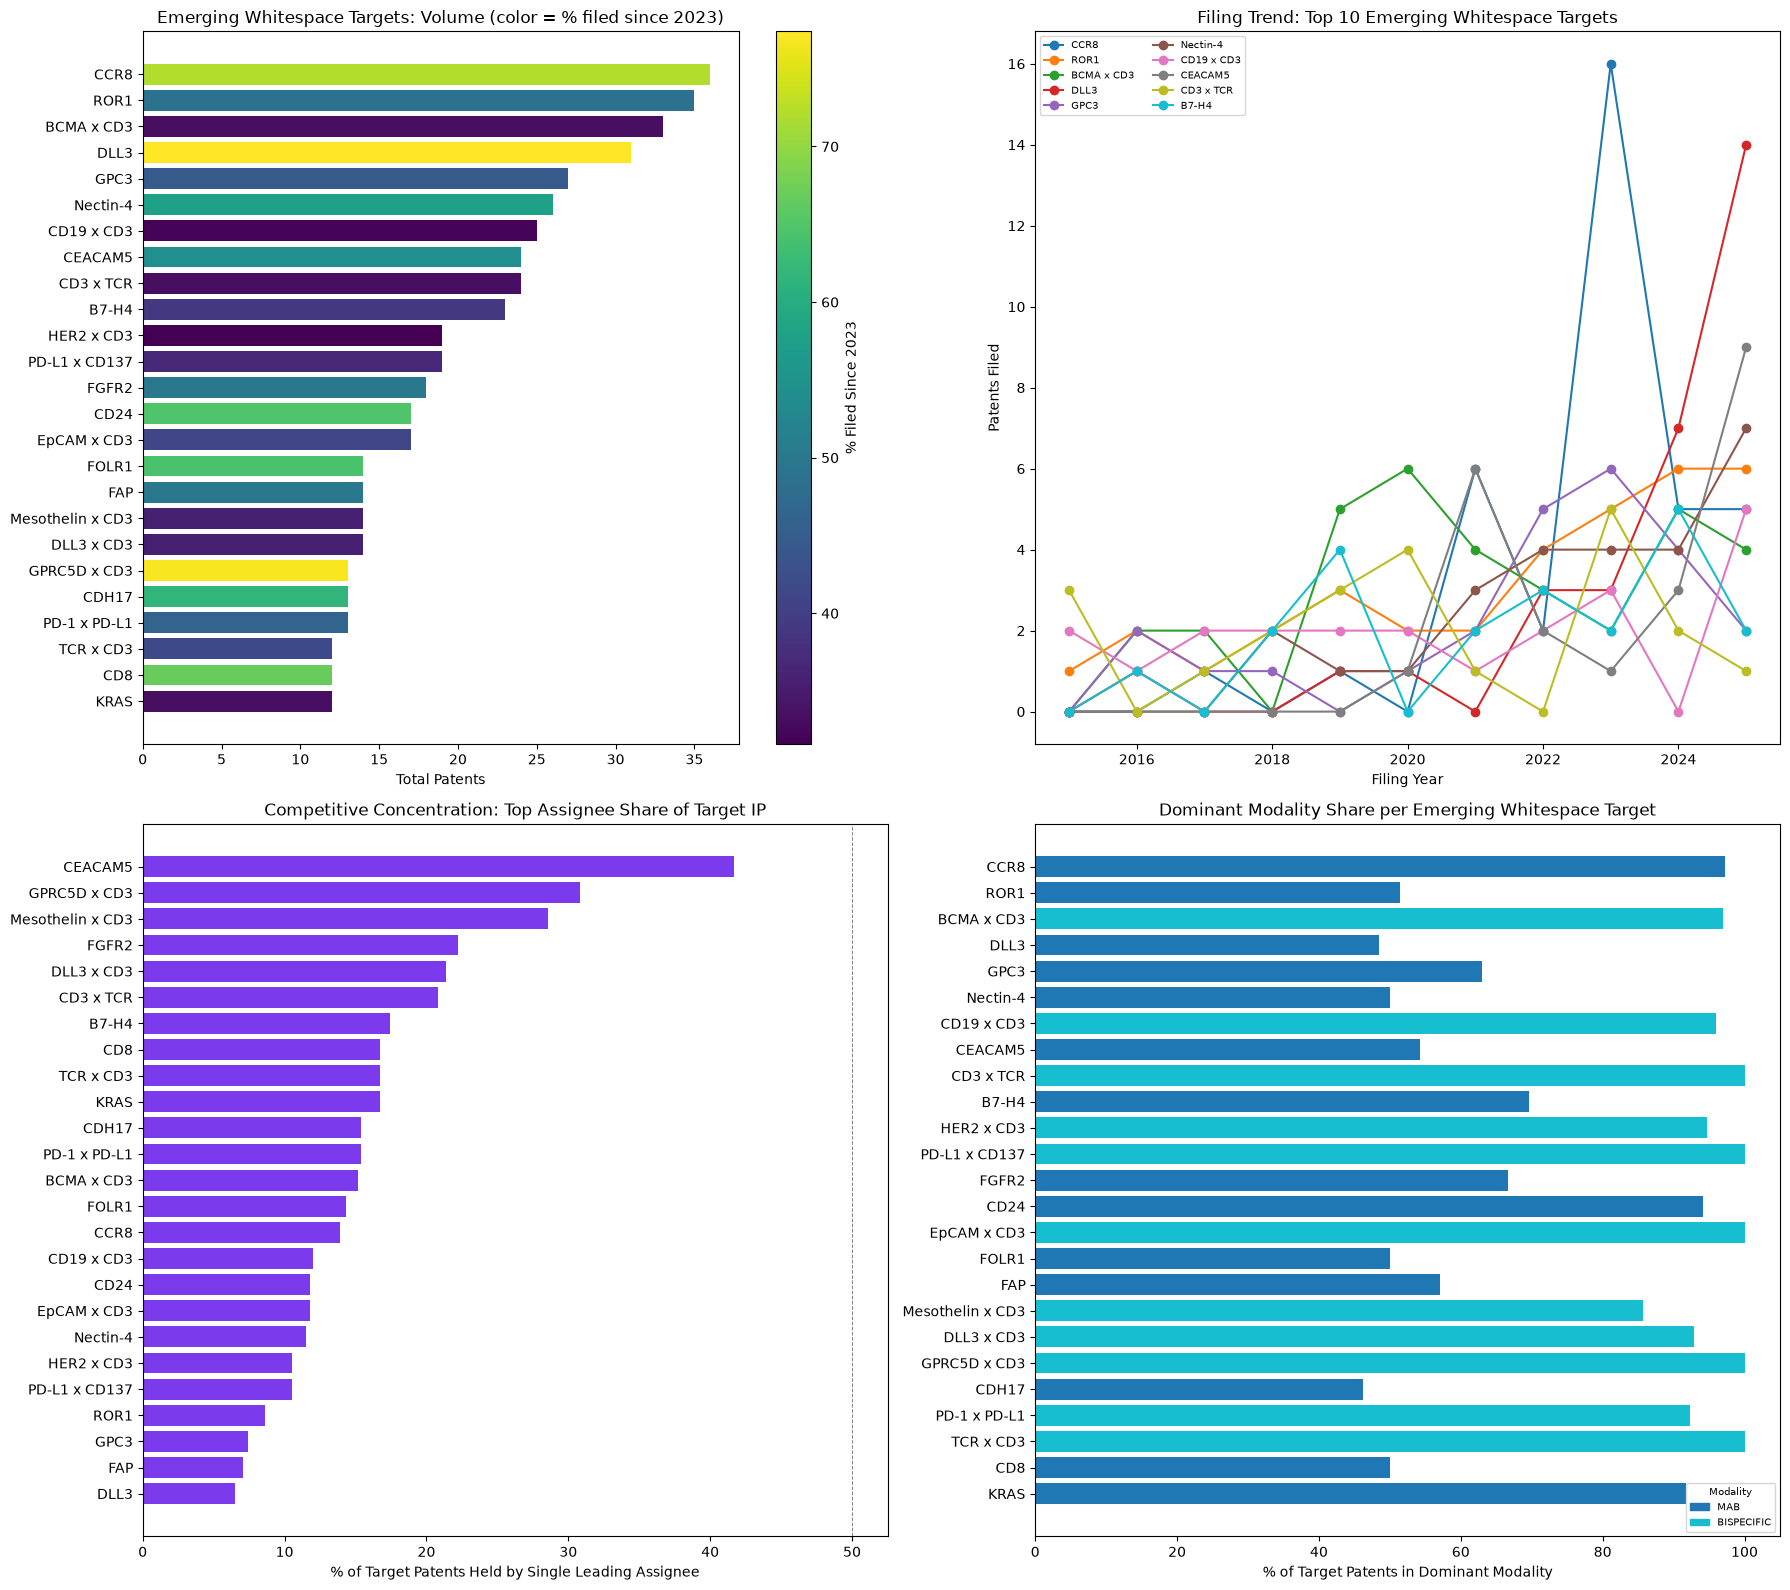

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Focus the bar charts on the top 25 emerging targets by total patent volume (most substantive whitespace candidates)
top25_emerging = emerging_deepdive_df.nlargest(25, 'total_patents').sort_values('total_patents')

# 1. Ranked bar of total patents, colored by recent momentum (pct_recent)
ax = axes[0, 0]
norm = mcolors.Normalize(vmin=top25_emerging['pct_recent'].min(), vmax=top25_emerging['pct_recent'].max())
colors = cm.viridis(norm(top25_emerging['pct_recent']))
bars = ax.barh(top25_emerging['target_name'], top25_emerging['total_patents'], color=colors)
ax.set_title('Emerging Whitespace Targets: Volume (color = % filed since 2023)')
ax.set_xlabel('Total Patents')
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
fig.colorbar(sm, ax=ax, label='% Filed Since 2023')

# 2. Year-by-year filing trend for the top 10 emerging targets by total patents
ax = axes[0, 1]
top10_names = emerging_deepdive_df.nlargest(10, 'total_patents')['target_name'].tolist()
trend_pivot = emerging_trend_df[emerging_trend_df['target_name'].isin(top10_names)].pivot(
    index='filing_year', columns='target_name', values='n').fillna(0)
trend_pivot = trend_pivot.reindex(columns=top10_names)
for name in top10_names:
    ax.plot(trend_pivot.index, trend_pivot[name], marker='o', label=name, linewidth=1.5)
ax.set_title('Filing Trend: Top 10 Emerging Whitespace Targets')
ax.set_xlabel('Filing Year')
ax.set_ylabel('Patents Filed')
ax.legend(fontsize=7, ncol=2)

# 3. Assignee concentration (top assignee's share of that target's IP) - lower = more fragmented/open
ax = axes[1, 0]
conc_sorted = top25_emerging.sort_values('top_assignee_share_pct')
ax.barh(conc_sorted['target_name'], conc_sorted['top_assignee_share_pct'], color='#7c3aed')
ax.set_title('Competitive Concentration: Top Assignee Share of Target IP')
ax.set_xlabel('% of Target Patents Held by Single Leading Assignee')
ax.axvline(50, color='black', linestyle='--', linewidth=0.7, alpha=0.5)

# 4. Dominant modality per target, colored by modality
ax = axes[1, 1]
modality_list = top25_emerging['dominant_modality'].unique().tolist()
modality_color_map = {m: cm.tab10(i / max(len(modality_list) - 1, 1)) for i, m in enumerate(modality_list)}
bar_colors = top25_emerging['dominant_modality'].map(modality_color_map)
ax.barh(top25_emerging['target_name'], top25_emerging['dominant_modality_pct'], color=bar_colors)
ax.set_title('Dominant Modality Share per Emerging Whitespace Target')
ax.set_xlabel('% of Target Patents in Dominant Modality')
handles = [plt.Rectangle((0, 0), 1, 1, color=modality_color_map[m]) for m in modality_list]
ax.legend(handles, modality_list, title='Modality', fontsize=7, title_fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

## Target x Modality x Tumor-Type Whitespace Grid

The most granular whitespace view: for the top 10 most-patented targets, cross the top 5 modalities against the top 8 tumor types to build a full combinatorial grid (10 x 5 x 8 = 400 cells). Cells with **zero patents** are genuine, unclaimed niches — a specific target pursued in a specific modality for a specific indication where no one has filed yet, even though the target itself is heavily patented overall. This distinguishes "the target is crowded" from "this exact modality+indication angle on the target is wide open."

In [10]:
sql_target_modality_indication_grid = f'''
WITH expanded AS (
  SELECT COALESCE(target_corrected, target) AS t, modality_only,
         TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS tumor
  FROM read_csv_auto('{csv_path.as_posix()}')
  WHERE indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
    AND COALESCE(target_corrected, target) IS NOT NULL
    AND modality_only IS NOT NULL
),
top_t AS (
  SELECT COALESCE(target_corrected, target) AS t, COUNT(*) n
  FROM read_csv_auto('{csv_path.as_posix()}') WHERE COALESCE(target_corrected, target) IS NOT NULL
  GROUP BY 1 ORDER BY n DESC LIMIT 10
),
top_i AS (SELECT tumor, COUNT(*) n FROM expanded GROUP BY 1 ORDER BY n DESC LIMIT 8),
top_m AS (SELECT modality_only, COUNT(*) n FROM expanded GROUP BY 1 ORDER BY n DESC LIMIT 5),
combos AS (
  SELECT top_t.t, top_m.modality_only, top_i.tumor
  FROM top_t CROSS JOIN top_m CROSS JOIN top_i
),
actual AS (
  SELECT t, modality_only, tumor, COUNT(*) n
  FROM expanded
  WHERE t IN (SELECT t FROM top_t) AND modality_only IN (SELECT modality_only FROM top_m) AND tumor IN (SELECT tumor FROM top_i)
  GROUP BY 1,2,3
)
SELECT combos.t AS target_name, combos.modality_only, combos.tumor AS indication,
       COALESCE(actual.n, 0) AS patent_count
FROM combos
LEFT JOIN actual ON actual.t = combos.t AND actual.modality_only = combos.modality_only AND actual.tumor = combos.tumor
ORDER BY combos.t, combos.modality_only, patent_count DESC;
'''

target_modality_indication_grid_df = con.sql(sql_target_modality_indication_grid).df()

n_cells = len(target_modality_indication_grid_df)
n_zero = int((target_modality_indication_grid_df['patent_count'] == 0).sum())

display(Markdown('### G. Target x Modality x Indication Whitespace Grid (top 10 targets x top 5 modalities x top 8 indications)'))
display(target_modality_indication_grid_df)

display(Markdown(f'**{n_zero} of {n_cells} cells ({n_zero/n_cells:.0%})** in this grid have zero patents — i.e. that exact target+modality+indication combination is unclaimed among the top targets/modalities/indications.'))

# Whitespace cell count per target: how many of the 40 possible modality x indication combos are still empty
whitespace_cells_per_target = (
    target_modality_indication_grid_df.assign(is_zero=lambda d: d['patent_count'] == 0)
    .groupby('target_name')['is_zero'].sum()
    .sort_values(ascending=False)
    .rename('zero_count_combos')
    .reset_index()
)
display(Markdown('### Whitespace Breadth by Target (count of empty modality x indication cells, out of 40 possible)'))
display(whitespace_cells_per_target)

### G. Target x Modality x Indication Whitespace Grid (top 10 targets x top 5 modalities x top 8 indications)

,target_name,modality_only,indication,patent_count
0,B7-H3,ADC,Lung,24
1,B7-H3,ADC,Prostate,10
2,B7-H3,ADC,Breast,10
3,B7-H3,ADC,Ovarian,7
4,B7-H3,ADC,Colorectal,7
...,...,...,...,...
395,TROP-2,MAB,Ovarian,0
396,TROP-2,MAB,Prostate,0
397,TROP-2,MAB,Breast,0
398,TROP-2,MAB,Colorectal,0


**204 of 400 cells (51%)** in this grid have zero patents — i.e. that exact target+modality+indication combination is unclaimed among the top targets/modalities/indications.

### Whitespace Breadth by Target (count of empty modality x indication cells, out of 40 possible)

,target_name,zero_count_combos
0,CD47,25
1,TCR,25
2,TROP-2,25
3,CTLA-4,23
4,PD-L1,23
5,HER2,22
6,EGFR,20
7,PD-1,17
8,B7-H3,16
9,CD3,8


### Target x Modality x Indication Charts

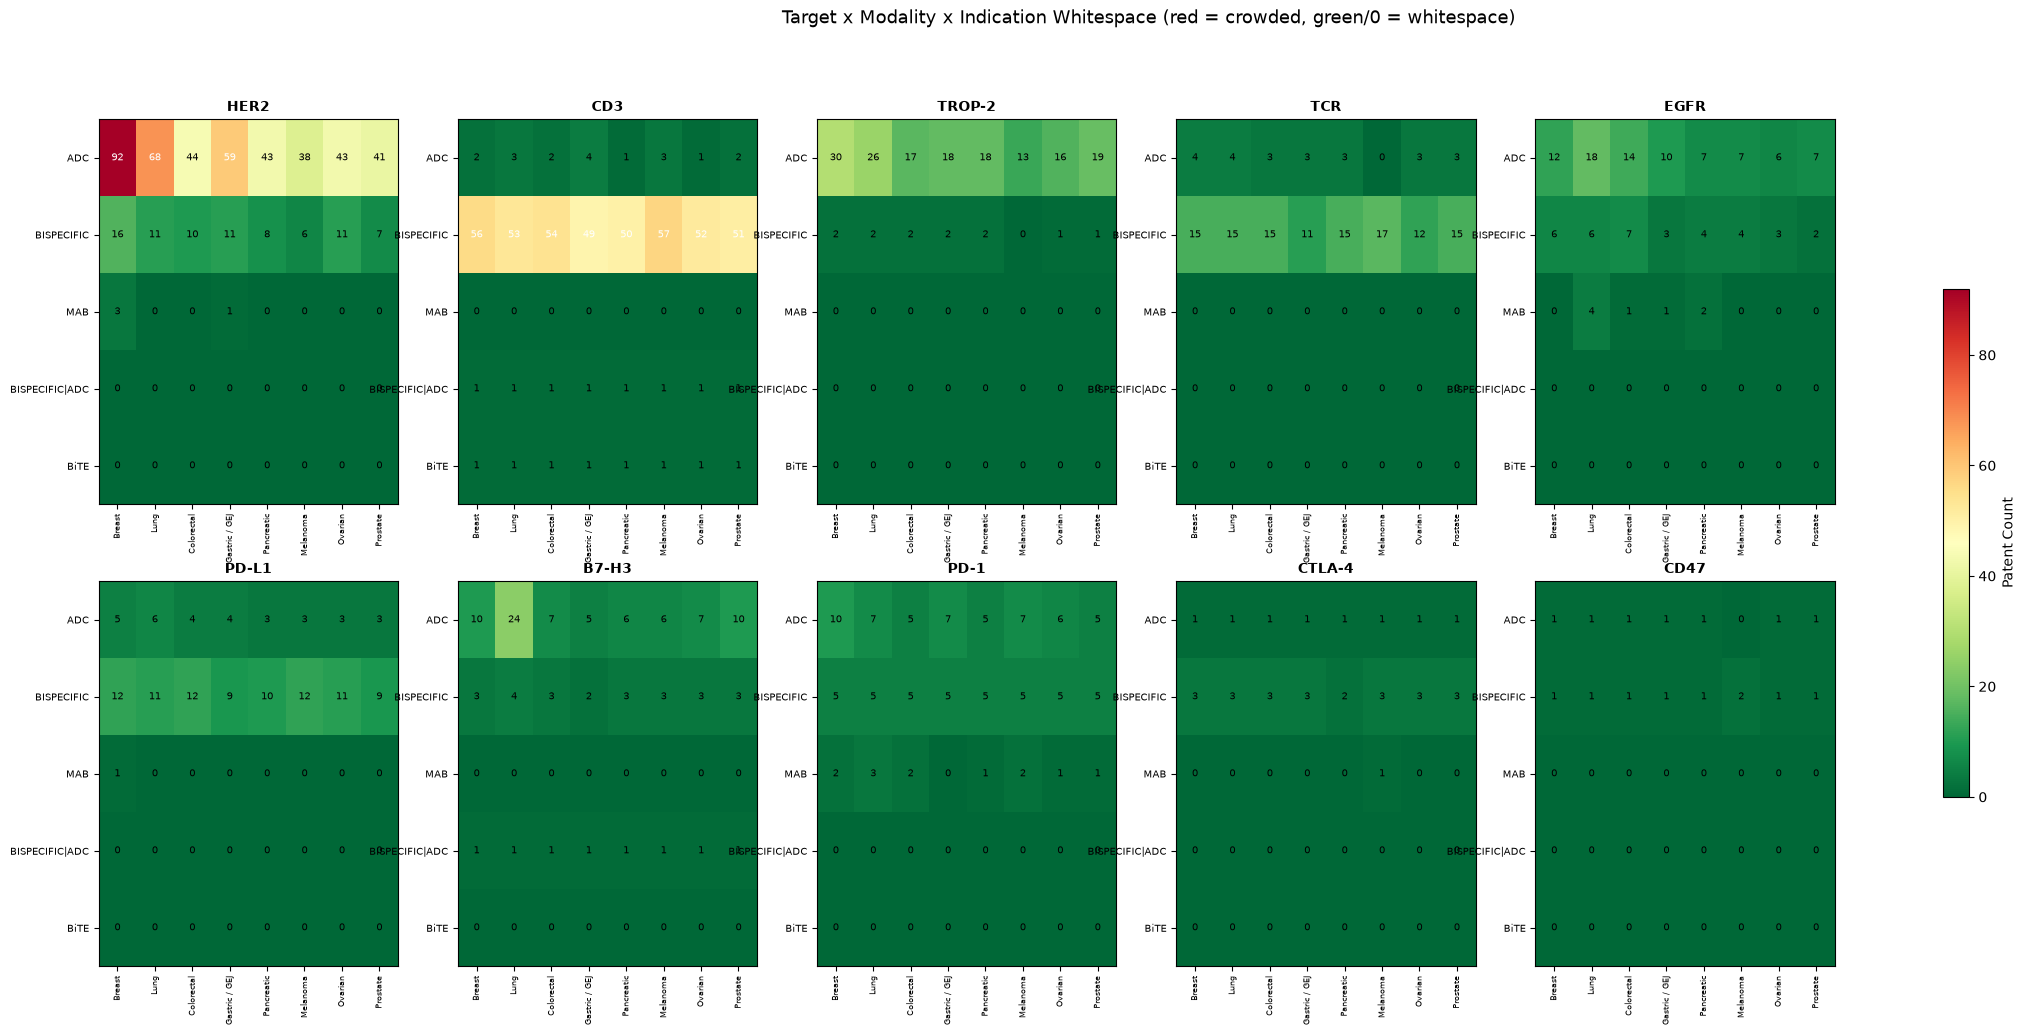

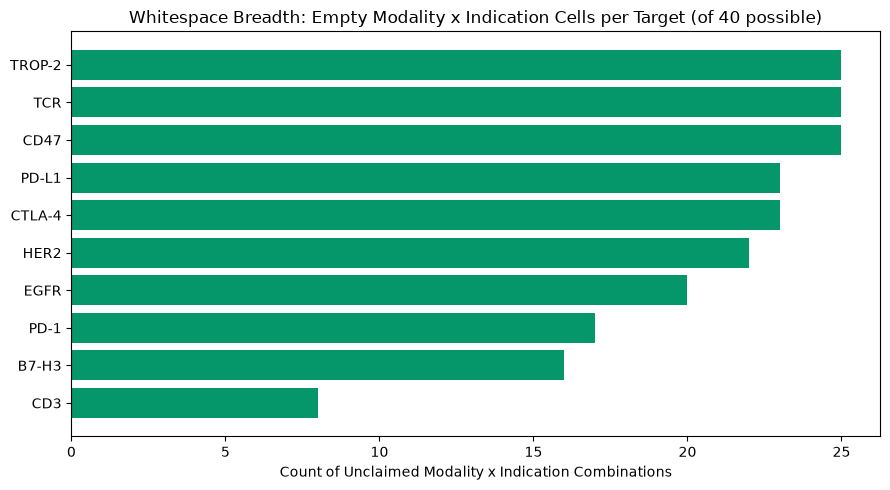

In [11]:
import matplotlib.pyplot as plt

# 1. Small-multiple heatmaps: one per target, modality (rows) x indication (columns), annotated with counts
target_order = target_modality_indication_grid_df.groupby('target_name')['patent_count'].sum().sort_values(ascending=False).index.tolist()
modality_order = target_modality_indication_grid_df.groupby('modality_only')['patent_count'].sum().sort_values(ascending=False).index.tolist()
indication_order = target_modality_indication_grid_df.groupby('indication')['patent_count'].sum().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(28, 11))
vmax = target_modality_indication_grid_df['patent_count'].max()
for ax, target in zip(axes.flat, target_order):
    sub = target_modality_indication_grid_df[target_modality_indication_grid_df['target_name'] == target]
    pivot = sub.pivot(index='modality_only', columns='indication', values='patent_count').reindex(
        index=modality_order, columns=indication_order).fillna(0)
    im = ax.imshow(pivot.values, cmap='RdYlGn_r', vmin=0, vmax=vmax, aspect='auto')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = int(pivot.values[i, j])
            ax.text(j, i, str(val), ha='center', va='center', fontsize=7,
                    color='white' if val > vmax * 0.5 else 'black')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=90, fontsize=6)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=7)
    ax.set_title(target, fontsize=10, fontweight='bold')
fig.suptitle('Target x Modality x Indication Whitespace (red = crowded, green/0 = whitespace)', fontsize=13)
fig.colorbar(im, ax=axes, shrink=0.6, label='Patent Count')
plt.show()

# 2. Whitespace breadth per target: how many of the 40 modality x indication cells are still empty
fig2, ax2 = plt.subplots(figsize=(9, 5))
wb = whitespace_cells_per_target.sort_values('zero_count_combos')
ax2.barh(wb['target_name'], wb['zero_count_combos'], color='#059669')
ax2.set_title('Whitespace Breadth: Empty Modality x Indication Cells per Target (of 40 possible)')
ax2.set_xlabel('Count of Unclaimed Modality x Indication Combinations')
plt.tight_layout()
plt.show()

## White Space Targets Available per Solid Tumor Indication

Final whitespace cut, at the request of the strategy interview: for each of the top 12 **solid tumor** indications (heme/liquid tumor types — leukemia, lymphoma, myeloma, CLL, AML, MDS, Hodgkin, Waldenstrom — are excluded so this is a pure solid-tumor view), cross-tab against the top 20 most-patented targets overall. A **zero-count cell** means that specific, already-validated (de-risked) target has **no patent filed for that indication** in this dataset — a concrete whitespace opportunity: a known target with no competitive claims yet in that particular solid tumor type. Indications are then ranked by whitespace breadth (how many of the 20 established targets remain unclaimed for that tumor type).


In [12]:
import pandas as pd

sql_solid_indication_target_grid = f'''
WITH expanded AS (
    SELECT COALESCE(target_corrected, target) AS t,
           TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS tumor
    FROM read_csv_auto('{csv_path.as_posix()}')
    WHERE indications IS NOT NULL AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
      AND COALESCE(target_corrected, target) IS NOT NULL
),
solid AS (
    SELECT t, tumor
    FROM expanded
    WHERE tumor NOT ILIKE '%leukemia%' AND tumor NOT ILIKE '%lymphoma%' AND tumor NOT ILIKE '%myeloma%'
      AND tumor NOT ILIKE '%CLL%' AND tumor NOT ILIKE '%AML%' AND tumor NOT ILIKE '%ALL%'
      AND tumor NOT ILIKE '%MDS%' AND tumor NOT ILIKE '%hodgkin%' AND tumor NOT ILIKE '%waldenstrom%'
      AND tumor NOT ILIKE '%blood%'
),
top_indications AS (
    SELECT tumor, COUNT(*) AS n FROM solid GROUP BY 1 ORDER BY n DESC LIMIT 12
),
top_targets AS (
    SELECT COALESCE(target_corrected, target) AS t, COUNT(*) AS n
    FROM read_csv_auto('{csv_path.as_posix()}')
    WHERE COALESCE(target_corrected, target) IS NOT NULL
    GROUP BY 1 ORDER BY n DESC LIMIT 20
),
combos AS (
    SELECT ti.tumor, tt.t
    FROM top_indications ti CROSS JOIN top_targets tt
),
actual AS (
    SELECT tumor, t, COUNT(*) AS n
    FROM solid
    WHERE tumor IN (SELECT tumor FROM top_indications) AND t IN (SELECT t FROM top_targets)
    GROUP BY 1, 2
)
SELECT combos.tumor AS indication, combos.t AS target_name, COALESCE(actual.n, 0) AS patent_count
FROM combos
LEFT JOIN actual ON actual.tumor = combos.tumor AND actual.t = combos.t
ORDER BY combos.tumor, patent_count DESC;
'''

solid_indication_target_grid_df = con.sql(sql_solid_indication_target_grid).df()

n_cells = len(solid_indication_target_grid_df)
n_zero = int((solid_indication_target_grid_df['patent_count'] == 0).sum())

display(Markdown('### H. Solid Tumor Indication x Target Whitespace Grid (top 12 solid tumor indications x top 20 targets)'))
display(solid_indication_target_grid_df)

display(Markdown(f'**{n_zero} of {n_cells} cells ({n_zero/n_cells:.0%})** have zero patents — i.e. that established target has no patent filed for that specific solid tumor indication in this dataset.'))

# Whitespace targets per indication: which of the 20 established targets are unclaimed for each indication
all_indications = solid_indication_target_grid_df['indication'].unique()
zero_df = solid_indication_target_grid_df[solid_indication_target_grid_df['patent_count'] == 0]
whitespace_targets_map = zero_df.groupby('indication')['target_name'].apply(lambda s: ', '.join(sorted(s)))
whitespace_count_map = zero_df.groupby('indication').size()

# Most crowded (highest patent count) target per indication, for context
top_crowded_df = (
    solid_indication_target_grid_df.sort_values('patent_count', ascending=False)
    .groupby('indication')
    .first()[['target_name', 'patent_count']]
    .rename(columns={'target_name': 'most_crowded_target', 'patent_count': 'most_crowded_target_patents'})
)

whitespace_per_indication_df = pd.DataFrame({'indication': all_indications})
whitespace_per_indication_df['whitespace_target_count'] = whitespace_per_indication_df['indication'].map(whitespace_count_map).fillna(0).astype(int)
whitespace_per_indication_df['whitespace_targets'] = whitespace_per_indication_df['indication'].map(whitespace_targets_map).fillna('(none — all 20 targets already claimed)')
whitespace_per_indication_df = whitespace_per_indication_df.merge(top_crowded_df, on='indication', how='left')
whitespace_per_indication_df = whitespace_per_indication_df.sort_values('whitespace_target_count', ascending=False).reset_index(drop=True)

display(Markdown('### Whitespace Targets Available per Solid Tumor Indication (out of 20 established targets considered)'))
display(whitespace_per_indication_df)


### H. Solid Tumor Indication x Target Whitespace Grid (top 12 solid tumor indications x top 20 targets)

,indication,target_name,patent_count
0,Breast,HER2,111
1,Breast,CD3,60
2,Breast,TROP-2,32
3,Breast,EGFR x MET,28
4,Breast,TCR,19
...,...,...,...
235,Sarcoma,TIGIT,2
236,Sarcoma,CD137,2
237,Sarcoma,CD47,1
238,Sarcoma,OX40,1


**17 of 240 cells (7%)** have zero patents — i.e. that established target has no patent filed for that specific solid tumor indication in this dataset.

### Whitespace Targets Available per Solid Tumor Indication (out of 20 established targets considered)

,indication,whitespace_target_count,whitespace_targets,most_crowded_target,most_crowded_target_patents
0,Breast,2,"Mesothelin, OX40",HER2,111
1,Colorectal,2,"Mesothelin, OX40",CD3,58
2,Gastric / GEJ,2,"Mesothelin, OX40",HER2,71
3,Glioblastoma / brain,2,"Mesothelin, OX40",CD3,50
4,Liver / HCC,2,"Mesothelin, OX40",CD3,43
5,Prostate,2,"Mesothelin, OX40",CD3,55
6,Kidney / RCC,1,OX40,CD3,47
7,Melanoma,1,Mesothelin,CD3,62
8,Ovarian,1,OX40,CD3,55
9,Pancreatic,1,OX40,CD3,53


### Solid Tumor Indication Whitespace Charts


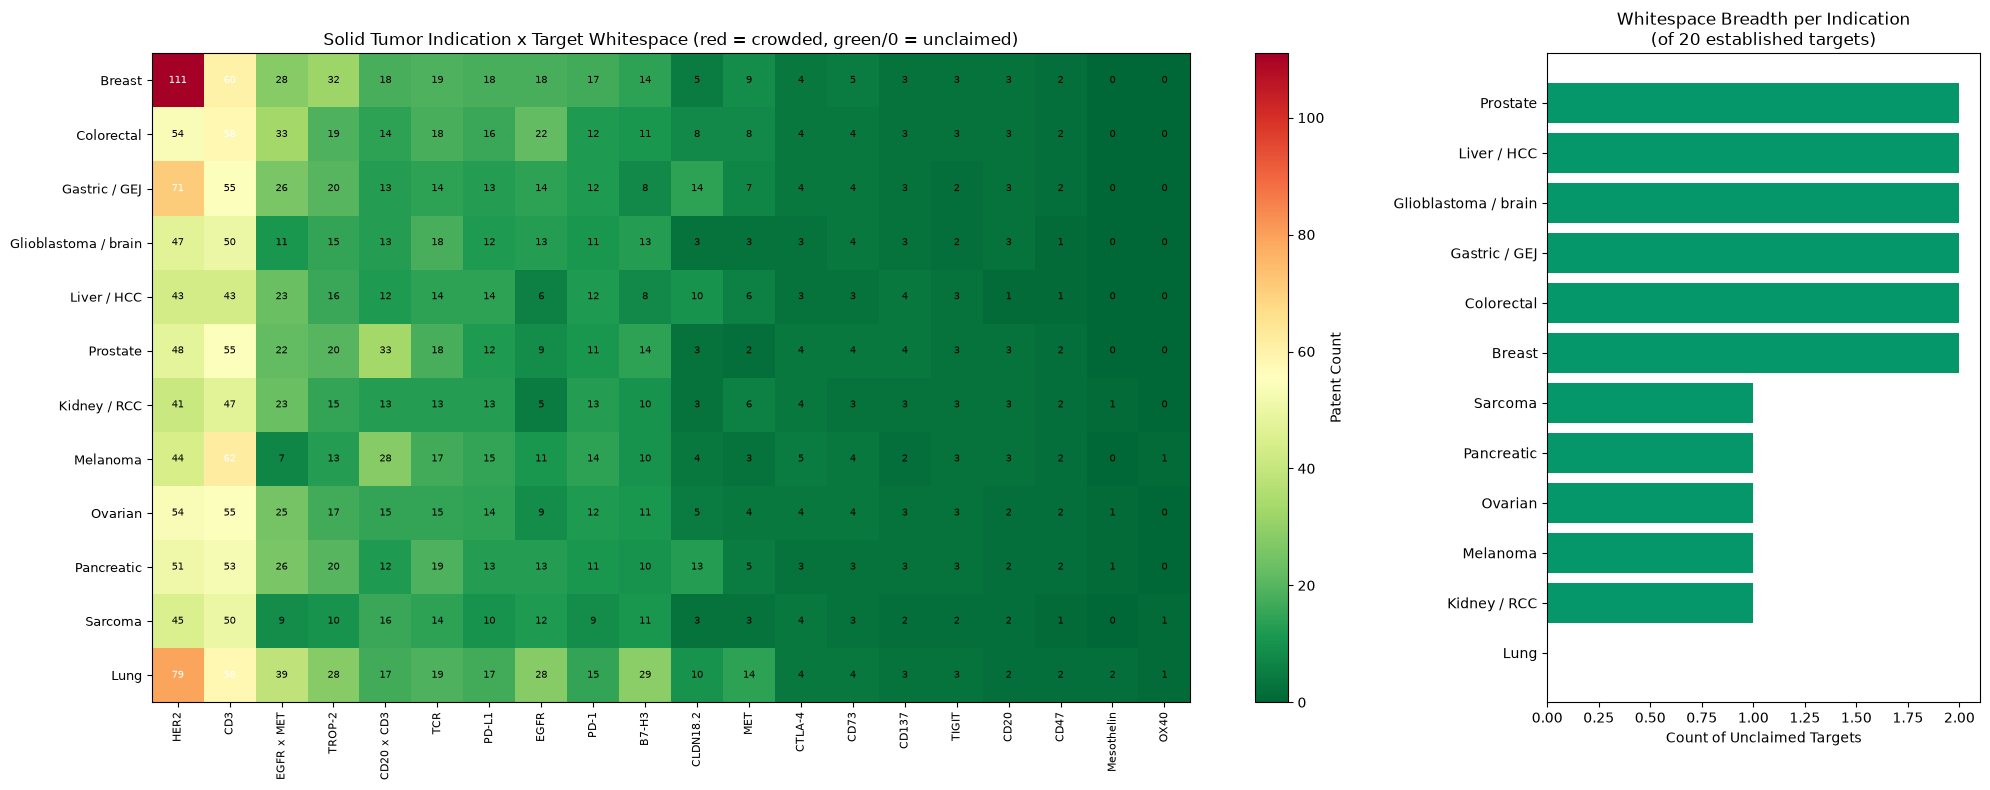

In [13]:
import matplotlib.pyplot as plt

indication_order = whitespace_per_indication_df.sort_values('whitespace_target_count', ascending=False)['indication'].tolist()
target_order = solid_indication_target_grid_df.groupby('target_name')['patent_count'].sum().sort_values(ascending=False).index.tolist()
pivot_it = solid_indication_target_grid_df.pivot(index='indication', columns='target_name', values='patent_count').reindex(index=indication_order, columns=target_order)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [3, 1]})

# 1. Heatmap: solid tumor indication x target, patent counts (red = crowded, green/0 = whitespace)
ax = axes[0]
vmax = pivot_it.values.max()
im = ax.imshow(pivot_it.values, cmap='RdYlGn_r', vmin=0, vmax=vmax, aspect='auto')
for i in range(pivot_it.shape[0]):
    for j in range(pivot_it.shape[1]):
        val = int(pivot_it.values[i, j])
        ax.text(j, i, str(val), ha='center', va='center', fontsize=7,
                color='white' if val > vmax * 0.5 else 'black')
ax.set_xticks(range(len(pivot_it.columns)))
ax.set_xticklabels(pivot_it.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(pivot_it.index)))
ax.set_yticklabels(pivot_it.index, fontsize=9)
ax.set_title('Solid Tumor Indication x Target Whitespace (red = crowded, green/0 = unclaimed)')
fig.colorbar(im, ax=ax, label='Patent Count')

# 2. Whitespace breadth per indication (count of unclaimed established targets, out of 20)
ax2 = axes[1]
wb = whitespace_per_indication_df.sort_values('whitespace_target_count')
ax2.barh(wb['indication'], wb['whitespace_target_count'], color='#059669')
ax2.set_title('Whitespace Breadth per Indication\n(of 20 established targets)')
ax2.set_xlabel('Count of Unclaimed Targets')

plt.tight_layout()
plt.show()
